# Notebook métier — Prédiction de `business_domain`

Ce notebook met en place un pipeline complet pour prédire la colonne **`business_domain`** à partir de métadonnées d’assets.

## Ce que contient le notebook
1. Chargement et audit rapide du dataset
2. Nettoyage et normalisation des colonnes texte
3. **Feature engineering**
   - ratios structurels
   - features de forme sur les noms techniques
   - compteurs de mots-clés métier
4. Représentation texte plus riche via **TF-IDF + TruncatedSVD**
5. Entraînement et évaluation d’un modèle **LightGBM**
6. Variante **CatBoost** sur représentation dense
7. Comparaison des résultats
8. Sauvegarde des artefacts du pipeline

## Remarques
- Le notebook **exclut les colonnes de fuite** (`business_domain_label`, `confidence`, `reason`, `labeling_notes`, etc.).
- Les métriques principales sont **Macro-F1** et **Weighted-F1**.
- La logique est conçue pour fonctionner sur le fichier :
  `dataset_asset_ml_run_5_for_labeling_sample_20000_enriched_annotated.csv`

In [1]:
# Installation silencieuse des dépendances si nécessaire
import importlib
import subprocess
import sys

REQUIRED_PACKAGES = ["lightgbm", "catboost", "joblib", "nbformat"]

for pkg in REQUIRED_PACKAGES:
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("Dépendances prêtes.")

Dépendances prêtes.


In [2]:
import os
import re
import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.svm import LinearSVC

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

## Configuration
Tu peux modifier `DATA_FILENAME` si tu renommes le fichier, ou forcer directement `DATA_PATH`.

In [3]:
RANDOM_STATE = 42
TEST_SIZE = 0.20

TARGET = "business_domain"

DATA_FILENAME = r"C:\Users\Salem\Desktop\Projets\pfe\Projet\exports\dataset_asset_ml_training_v5_remapped.csv"

DROP_COLS = [
    "run_id",
    "asset_id",
    "business_domain_label",
    "labeling_notes",
    "confidence",
    "reason",
]

TEXT_COLS_CHAR = [
    "technical_name",
    "source_ref",
]

TEXT_COLS_WORD = [
    "column_names_text",
    "column_type_signature_text",
    "column_value_semantics_text",
    "column_sample_values_text",
    "column_observed_pattern_text",
]

NUM_COLS = [
    "field_count",
    "nullable_field_count",
    "non_nullable_field_count",
    "numeric_field_count",
    "date_field_count",
    "text_field_count",
    "large_text_field_count",
    "avg_data_length",
    "max_data_length",
    "row_count",
    "size_bytes",
    "size_mb",
]

CAT_COLS = [
    "source_system",
    "asset_type",
    "has_profile_data",
]

RUN_BASELINE = True
RUN_LIGHTGBM = True
RUN_CATBOOST = True

CHAR_MAX_FEATURES = 30000
WORD_MAX_FEATURES = 40000
CHAR_SVD_COMPONENTS = 50
WORD_SVD_COMPONENTS = 60

In [4]:
def resolve_data_path(filename: str) -> Path:
    candidates = [
        Path(filename),
        Path.cwd() / filename,
        Path("/mnt/data") / filename,
        Path("/content") / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"Impossible de trouver le fichier '{filename}'. "
        "Place le CSV à côté du notebook ou modifie DATA_FILENAME / DATA_PATH."
    )

DATA_PATH = resolve_data_path(DATA_FILENAME)
print("DATA_PATH =", DATA_PATH)

DATA_PATH = C:\Users\Salem\Desktop\Projets\pfe\Projet\exports\dataset_asset_ml_training_v5_remapped.csv


## Chargement et audit initial

In [5]:
df_raw = pd.read_csv(DATA_PATH)

print("Shape :", df_raw.shape)
display(df_raw.head(3))
print("\nColonnes :")
print(df_raw.columns.tolist())

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe9 in position 7272: invalid continuation byte

,count
business_domain,
Finance & Contrôle,7509
IT & Sécurité,5303
Other,2321
Achats & Fournisseurs,2165
Supply Chain / Logistique / Production,1502
RH,855
Ventes & Clients,345


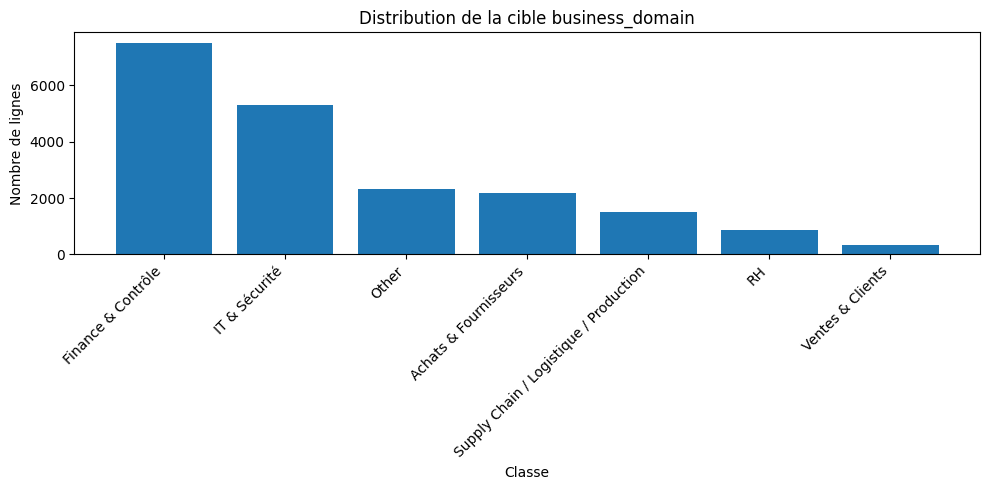

In [ ]:
target_counts = df_raw[TARGET].value_counts(dropna=False).sort_values(ascending=False)
display(target_counts.to_frame("count"))

plt.figure(figsize=(10, 5))
plt.bar(target_counts.index.astype(str), target_counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Distribution de la cible business_domain")
plt.xlabel("Classe")
plt.ylabel("Nombre de lignes")
plt.tight_layout()
plt.show()

In [ ]:
missing_ratio = (df_raw.isna().mean() * 100).sort_values(ascending=False)
display(missing_ratio.to_frame("missing_pct").head(20))

print("Colonnes candidates à exclure pour fuite / bruit :")
print(DROP_COLS)

,missing_pct
labeling_notes,100.000
business_domain_label,100.000
column_sample_values_text,99.865
column_observed_pattern_text,99.865
size_bytes,0.330
size_mb,0.330
row_count,0.330
business_domain_raw,0.100
run_id,0.000
non_nullable_field_count,0.000


Colonnes candidates à exclure pour fuite / bruit :
['run_id', 'asset_id', 'business_domain_label', 'labeling_notes', 'confidence', 'reason']


## Prétraitement et feature engineering

### Principes
- Normaliser les textes
- Garder séparément :
  - les colonnes texte de **nommage technique** (`technical_name`, `source_ref`)
  - les colonnes texte de **contenu métier / sémantique**
- Créer des variables supplémentaires :
  - ratios structurels
  - logs sur les volumes
  - features de forme
  - compteurs de mots-clés métier

In [ ]:
DOMAIN_KEYWORDS = {
    "finance": [
        "invoice", "payment", "ledger", "gl", "tax", "budget", "amount",
        "cost", "expense", "revenue", "accounting", "journal"
    ],
    "hr": [
        "employee", "empl", "job", "manager", "payroll", "absence",
        "position", "hire", "worker", "salary", "person", "headcount"
    ],
    "it": [
        "user", "role", "access", "auth", "permission", "config",
        "server", "system", "account", "login", "application", "security"
    ],
    "procurement": [
        "vendor", "supplier", "purchase", "po", "item", "stock",
        "inventory", "material", "order", "sourcing"
    ],
    "sales": [
        "customer", "client", "opportunity", "quote", "deal",
        "crm", "sales", "pipeline", "booking"
    ],
    "marketing": [
        "campaign", "lead", "segment", "channel",
        "audience", "click", "impression", "conversion"
    ],
    "risk": [
        "risk", "control", "audit", "incident",
        "compliance", "issue", "mitigation", "policy"
    ],
    "supply_chain": [
        "shipment", "warehouse", "inventory", "delivery",
        "route", "transport", "plant", "logistics"
    ],
}

In [ ]:
def normalize_text(x: str) -> str:
    if pd.isna(x):
        return ""
    x = str(x).lower()

    separators = ["_", "-", "|", "/", "\\", ".", ":", ";", ",", "(", ")", "[", "]", "{", "}"]
    for sep in separators:
        x = x.replace(sep, " ")

    x = re.sub(r"[^a-z0-9\s]", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x


def safe_div(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return np.divide(a, b, out=np.zeros_like(a, dtype=float), where=b != 0)


def prepare_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df.drop(columns=DROP_COLS, errors="ignore")

    for col in TEXT_COLS_CHAR + TEXT_COLS_WORD:
        if col in df.columns:
            df[col] = df[col].apply(normalize_text)

    for col in CAT_COLS:
        if col in df.columns:
            df[col] = df[col].fillna("missing").astype(str)

    for col in NUM_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)

    df[TARGET] = df[TARGET].astype(str)
    return df


def build_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)

    field_count = df["field_count"].fillna(0).astype(float).values

    out["ratio_numeric"] = safe_div(df["numeric_field_count"].fillna(0), field_count)
    out["ratio_date"] = safe_div(df["date_field_count"].fillna(0), field_count)
    out["ratio_text"] = safe_div(df["text_field_count"].fillna(0), field_count)
    out["ratio_large_text"] = safe_div(df["large_text_field_count"].fillna(0), field_count)
    out["ratio_nullable"] = safe_div(df["nullable_field_count"].fillna(0), field_count)
    out["ratio_non_nullable"] = safe_div(df["non_nullable_field_count"].fillna(0), field_count)

    out["log_row_count"] = np.log1p(df["row_count"].fillna(0).astype(float))
    out["log_size_bytes"] = np.log1p(df["size_bytes"].fillna(0).astype(float))
    out["log_size_mb"] = np.log1p(df["size_mb"].fillna(0).astype(float))
    out["log_avg_data_length"] = np.log1p(df["avg_data_length"].fillna(0).astype(float))
    out["log_max_data_length"] = np.log1p(df["max_data_length"].fillna(0).astype(float))
    out["avg_size_per_field"] = safe_div(df["size_bytes"].fillna(0), np.maximum(field_count, 1))

    for prefix in ["technical_name", "source_ref"]:
        s = df[prefix].fillna("").astype(str)

        out[f"{prefix}_len"] = s.str.len()
        out[f"{prefix}_token_count"] = s.str.count(r"[A-Za-z0-9]+")
        out[f"{prefix}_digit_count"] = s.str.count(r"\d")
        out[f"{prefix}_underscore_count"] = s.str.count(r"_")
        out[f"{prefix}_upper_ratio"] = s.apply(
            lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1)
        )
        out[f"{prefix}_has_id"] = s.str.contains(r"id", case=False, regex=True).astype(int)
        out[f"{prefix}_has_dt"] = s.str.contains(r"dt|date", case=False, regex=True).astype(int)
        out[f"{prefix}_has_amt"] = s.str.contains(r"amt|amount", case=False, regex=True).astype(int)
        out[f"{prefix}_has_cd"] = s.str.contains(r"cd|code", case=False, regex=True).astype(int)

    combined_text = (
        df["technical_name"].fillna("").astype(str) + " " +
        df["source_ref"].fillna("").astype(str) + " " +
        df["column_names_text"].fillna("").astype(str) + " " +
        df["column_value_semantics_text"].fillna("").astype(str)
    ).str.lower()

    for domain, keywords in DOMAIN_KEYWORDS.items():
        pattern = r"\b(" + "|".join(re.escape(k) for k in keywords) + r")\b"
        out[f"{domain}_keyword_count"] = combined_text.str.count(pattern)
        out[f"has_{domain}_keyword"] = (out[f"{domain}_keyword_count"] > 0).astype(int)

    return out.fillna(0)


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)

In [ ]:
df = prepare_dataframe(df_raw)

print("Shape après préparation :", df.shape)
display(df.head(2))

Shape après préparation : (20000, 29)


,source_system,asset_type,technical_name,source_ref,field_count,nullable_field_count,non_nullable_field_count,numeric_field_count,date_field_count,text_field_count,large_text_field_count,avg_data_length,max_data_length,row_count,size_bytes,size_mb,has_profile_data,column_names_text,column_type_signature_text,column_value_semantics_text,column_sample_values_text,column_observed_pattern_text,business_domain_raw,business_domain,llm_consensus_score,llm_votes_json,llm_models_used,llm_prompt_version,llm_status
0,oracle,oracle_table,sysadm ps access grp tbl,ps access grp tbl,3,1,2,0,0,3,1,16.666667,30,525.0,40425.0,0.038552,True,access group descr descrlong,access group varchar2 descr varchar2 descrlong...,access group classification descr label descrl...,access group account distribution accounting a...,access group short code like descr free text like,IT,IT & Sécurité,1.0,"[{""model"": ""qwen2.5:32b-instruct"", ""variant"": ...",qwen2.5:32b-instruct,business_domain_v4_direct_mapping_fr,ok
1,oracle,oracle_table,sysadm ps accomplish lang,ps accomplish lang,12,1,11,0,1,11,0,19.333333,50,0.0,0.0,0.000000,True,accomplishment dt issued educator emplid grant...,accomplishment varchar2 dt issued date educato...,accomplishment label dt issued date or timesta...,,,HR,RH,1.0,"[{""model"": ""qwen2.5:32b-instruct"", ""variant"": ...",qwen2.5:32b-instruct,business_domain_v4_direct_mapping_fr,ok


## Split train / test
On conserve un split **stratifié** pour préserver la distribution de la cible.

In [ ]:
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(str)

label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_enc,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_enc,
)

print("Train shape :", X_train.shape)
print("Test shape  :", X_test.shape)
print("Classes :", list(label_encoder.classes_))

Train shape : (16000, 28)
Test shape  : (4000, 28)
Classes : ['Achats & Fournisseurs', 'Finance & Contrôle', 'IT & Sécurité', 'Other', 'RH', 'Supply Chain / Logistique / Production', 'Ventes & Clients']


## Représentation texte : TF-IDF + TruncatedSVD

### Stratégie
- `technical_name` et `source_ref` → **char n-grams**
- textes sémantiques → **word n-grams**
- réduction de dimension via **SVD**

In [ ]:
def vectorize_text_blocks_svd(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    text_cols_char,
    text_cols_word,
    char_max_features=30000,
    word_max_features=40000,
    char_svd_components=50,
    word_svd_components=60,
):
    train_sparse_blocks = []
    test_sparse_blocks = []

    train_dense_frames = []
    test_dense_frames = []

    feature_names = []
    fitted_text_objects = {}

    # 1) Colonnes char n-grams
    for col in text_cols_char:
        if col not in X_train.columns:
            continue

        vec = TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=3,
            max_features=char_max_features,
        )

        Xtr = vec.fit_transform(X_train[col])
        Xte = vec.transform(X_test[col])

        if Xtr.shape[1] < 2:
            print(f"[SKIP] {col} : vocabulaire trop faible pour SVD.")
            continue

        n_comp = max(2, min(char_svd_components, Xtr.shape[1] - 1))
        svd = TruncatedSVD(n_components=n_comp, random_state=RANDOM_STATE)

        Xtr_svd = svd.fit_transform(Xtr)
        Xte_svd = svd.transform(Xte)

        block_feature_names = [f"{col}__svd_{i+1}" for i in range(n_comp)]

        train_sparse_blocks.append(csr_matrix(Xtr_svd))
        test_sparse_blocks.append(csr_matrix(Xte_svd))

        train_dense_frames.append(pd.DataFrame(Xtr_svd, index=X_train.index, columns=block_feature_names))
        test_dense_frames.append(pd.DataFrame(Xte_svd, index=X_test.index, columns=block_feature_names))

        feature_names.extend(block_feature_names)
        fitted_text_objects[col] = {"vectorizer": vec, "svd": svd}

    # 2) Colonnes word n-grams
    for col in text_cols_word:
        if col not in X_train.columns:
            continue

        if X_train[col].astype(str).str.strip().eq("").all():
            print(f"[SKIP] {col} : colonne vide.")
            continue

        vec = TfidfVectorizer(
            analyzer="word",
            token_pattern=r"(?u)\b\w+\b",
            ngram_range=(1, 2),
            min_df=3,
            max_features=word_max_features,
        )

        try:
            Xtr = vec.fit_transform(X_train[col])
            Xte = vec.transform(X_test[col])
        except ValueError:
            print(f"[SKIP] {col} : vocabulaire vide.")
            continue

        if Xtr.shape[1] < 2:
            print(f"[SKIP] {col} : vocabulaire trop faible pour SVD.")
            continue

        n_comp = max(2, min(word_svd_components, Xtr.shape[1] - 1))
        svd = TruncatedSVD(n_components=n_comp, random_state=RANDOM_STATE)

        Xtr_svd = svd.fit_transform(Xtr)
        Xte_svd = svd.transform(Xte)

        block_feature_names = [f"{col}__svd_{i+1}" for i in range(n_comp)]

        train_sparse_blocks.append(csr_matrix(Xtr_svd))
        test_sparse_blocks.append(csr_matrix(Xte_svd))

        train_dense_frames.append(pd.DataFrame(Xtr_svd, index=X_train.index, columns=block_feature_names))
        test_dense_frames.append(pd.DataFrame(Xte_svd, index=X_test.index, columns=block_feature_names))

        feature_names.extend(block_feature_names)
        fitted_text_objects[col] = {"vectorizer": vec, "svd": svd}

    X_train_text_sparse = hstack(train_sparse_blocks).tocsr()
    X_test_text_sparse = hstack(test_sparse_blocks).tocsr()

    X_train_text_dense = pd.concat(train_dense_frames, axis=1)
    X_test_text_dense = pd.concat(test_dense_frames, axis=1)

    return {
        "X_train_text_sparse": X_train_text_sparse,
        "X_test_text_sparse": X_test_text_sparse,
        "X_train_text_dense": X_train_text_dense,
        "X_test_text_dense": X_test_text_dense,
        "feature_names": feature_names,
        "fitted_objects": fitted_text_objects,
    }

In [ ]:
text_blocks = vectorize_text_blocks_svd(
    X_train,
    X_test,
    text_cols_char=TEXT_COLS_CHAR,
    text_cols_word=TEXT_COLS_WORD,
    char_max_features=CHAR_MAX_FEATURES,
    word_max_features=WORD_MAX_FEATURES,
    char_svd_components=CHAR_SVD_COMPONENTS,
    word_svd_components=WORD_SVD_COMPONENTS,
)

print("Text sparse train shape :", text_blocks["X_train_text_sparse"].shape)
print("Text sparse test shape  :", text_blocks["X_test_text_sparse"].shape)
print("Nb de features texte compressées :", len(text_blocks["feature_names"]))

Text sparse train shape : (16000, 387)
Text sparse test shape  : (4000, 387)
Nb de features texte compressées : 387


## Blocs tabulaires
- numériques bruts
- features métier dérivées
- catégorielles encodées

In [ ]:
def build_tabular_blocks(X_train: pd.DataFrame, X_test: pd.DataFrame):
    engineered_train = build_engineered_features(X_train)
    engineered_test = build_engineered_features(X_test)

    base_num_train = X_train[NUM_COLS].fillna(0).astype(float)
    base_num_test = X_test[NUM_COLS].fillna(0).astype(float)

    ohe = make_one_hot_encoder()
    X_train_cat = ohe.fit_transform(X_train[CAT_COLS])
    X_test_cat = ohe.transform(X_test[CAT_COLS])

    numeric_train_df = pd.concat(
        [base_num_train.reset_index(drop=True), engineered_train.reset_index(drop=True)],
        axis=1
    )
    numeric_test_df = pd.concat(
        [base_num_test.reset_index(drop=True), engineered_test.reset_index(drop=True)],
        axis=1
    )

    X_train_num_sparse = csr_matrix(numeric_train_df.values)
    X_test_num_sparse = csr_matrix(numeric_test_df.values)

    cat_feature_names = list(ohe.get_feature_names_out(CAT_COLS))
    all_feature_names = list(numeric_train_df.columns) + cat_feature_names

    X_train_tab_sparse = hstack([X_train_num_sparse, X_train_cat]).tocsr()
    X_test_tab_sparse = hstack([X_test_num_sparse, X_test_cat]).tocsr()

    # Pour CatBoost, on garde les catégorielles sous forme native
    X_train_dense_for_catboost = pd.concat(
        [
            numeric_train_df.set_index(X_train.index),
            X_train[CAT_COLS],
        ],
        axis=1
    )

    X_test_dense_for_catboost = pd.concat(
        [
            numeric_test_df.set_index(X_test.index),
            X_test[CAT_COLS],
        ],
        axis=1
    )

    return {
        "X_train_tab_sparse": X_train_tab_sparse,
        "X_test_tab_sparse": X_test_tab_sparse,
        "feature_names": all_feature_names,
        "ohe": ohe,
        "numeric_train_df": numeric_train_df.set_index(X_train.index),
        "numeric_test_df": numeric_test_df.set_index(X_test.index),
        "X_train_dense_for_catboost": X_train_dense_for_catboost,
        "X_test_dense_for_catboost": X_test_dense_for_catboost,
    }

In [ ]:
tab_blocks = build_tabular_blocks(X_train, X_test)

print("Tab sparse train shape :", tab_blocks["X_train_tab_sparse"].shape)
print("Tab sparse test shape  :", tab_blocks["X_test_tab_sparse"].shape)
print("Nb de features tabulaires :", len(tab_blocks["feature_names"]))

Tab sparse train shape : (16000, 63)
Tab sparse test shape  : (4000, 63)
Nb de features tabulaires : 63


## Assemblage final

In [ ]:
X_train_final_sparse = hstack(
    [
        text_blocks["X_train_text_sparse"],
        tab_blocks["X_train_tab_sparse"],
    ]
).tocsr()

X_test_final_sparse = hstack(
    [
        text_blocks["X_test_text_sparse"],
        tab_blocks["X_test_tab_sparse"],
    ]
).tocsr()

all_sparse_feature_names = text_blocks["feature_names"] + tab_blocks["feature_names"]

print("X_train_final_sparse :", X_train_final_sparse.shape)
print("X_test_final_sparse  :", X_test_final_sparse.shape)

X_train_final_sparse : (16000, 450)
X_test_final_sparse  : (4000, 450)


## Fonctions d’évaluation

In [ ]:
def evaluate_predictions(y_true, y_pred, label_encoder, model_name="model"):
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    print(f"{model_name} - Macro F1    : {macro_f1:.4f}")
    print(f"{model_name} - Weighted F1 : {weighted_f1:.4f}")
    print()

    report = classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_,
        digits=4,
        output_dict=True
    )
    report_df = pd.DataFrame(report).T
    display(report_df)

    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)

    plt.figure(figsize=(10, 8))
    plt.imshow(cm_df.values, aspect="auto")
    plt.xticks(range(len(cm_df.columns)), cm_df.columns, rotation=45, ha="right")
    plt.yticks(range(len(cm_df.index)), cm_df.index)
    plt.title(f"Matrice de confusion — {model_name}")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    return {
        "model_name": model_name,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "report_df": report_df,
        "confusion_matrix": cm_df,
    }

## Baseline optionnelle — Linear SVM
Cette baseline sert de point de comparaison rapide.

LinearSVC baseline - Macro F1    : 0.1569
LinearSVC baseline - Weighted F1 : 0.3001



,precision,recall,f1-score,support
Achats & Fournisseurs,0.000000,0.000000,0.000000,433.000
Finance & Contrôle,0.521875,0.778296,0.624800,1502.000
IT & Sécurité,0.736842,0.052780,0.098505,1061.000
Other,0.289562,0.370690,0.325142,464.000
RH,0.000000,0.000000,0.000000,171.000
Supply Chain / Logistique / Production,0.400000,0.006667,0.013115,300.000
Ventes & Clients,0.019409,0.304348,0.036490,69.000
accuracy,0.355000,0.355000,0.355000,0.355
macro avg,0.281098,0.216111,0.156864,4000.000
weighted avg,0.455335,0.355000,0.300070,4000.000


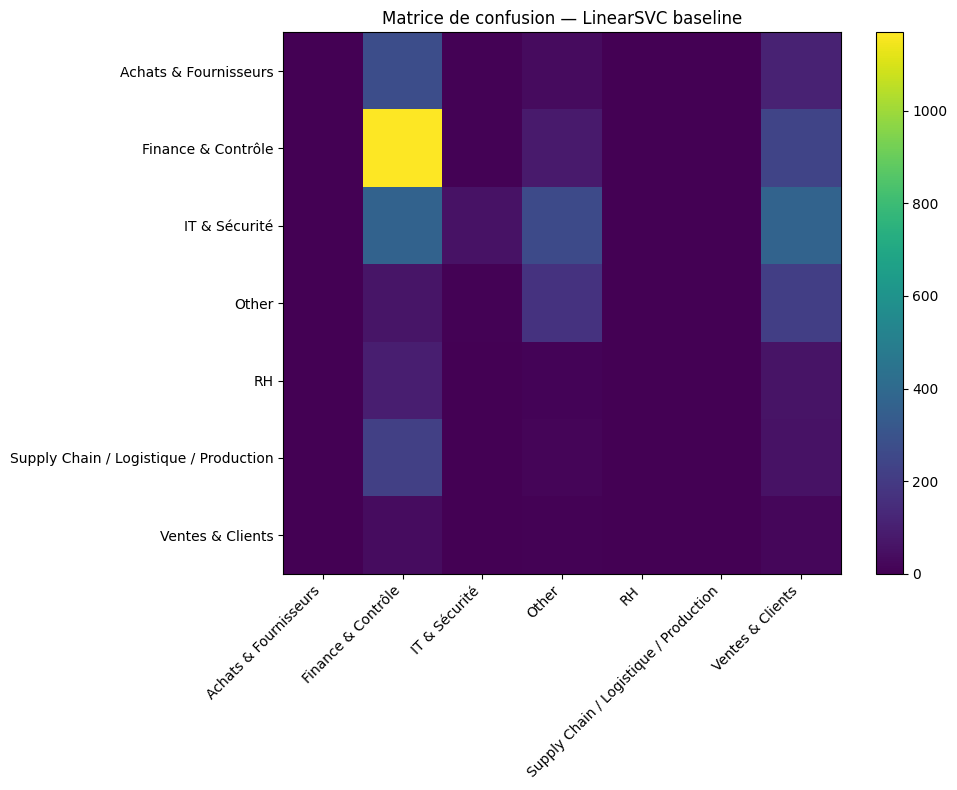

In [ ]:
results_summary = []

if RUN_BASELINE:
    baseline_model = LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )
    baseline_model.fit(X_train_final_sparse, y_train)
    baseline_preds = baseline_model.predict(X_test_final_sparse)

    baseline_eval = evaluate_predictions(
        y_test,
        baseline_preds,
        label_encoder,
        model_name="LinearSVC baseline"
    )
    results_summary.append(
        {
            "model": "LinearSVC baseline",
            "macro_f1": baseline_eval["macro_f1"],
            "weighted_f1": baseline_eval["weighted_f1"],
        }
    )

## Modèle 1 — LightGBM

LightGBM - Macro F1    : 0.8377
LightGBM - Weighted F1 : 0.8813



,precision,recall,f1-score,support
Achats & Fournisseurs,0.917258,0.896074,0.906542,433.00000
Finance & Contrôle,0.952120,0.926764,0.939271,1502.00000
IT & Sécurité,0.860806,0.885957,0.873200,1061.00000
Other,0.719101,0.827586,0.769539,464.00000
RH,0.870229,0.666667,0.754967,171.00000
Supply Chain / Logistique / Production,0.856187,0.853333,0.854758,300.00000
Ventes & Clients,0.830508,0.710145,0.765625,69.00000
accuracy,0.880750,0.880750,0.880750,0.88075
macro avg,0.858030,0.823789,0.837700,4000.00000
weighted avg,0.884301,0.880750,0.881301,4000.00000


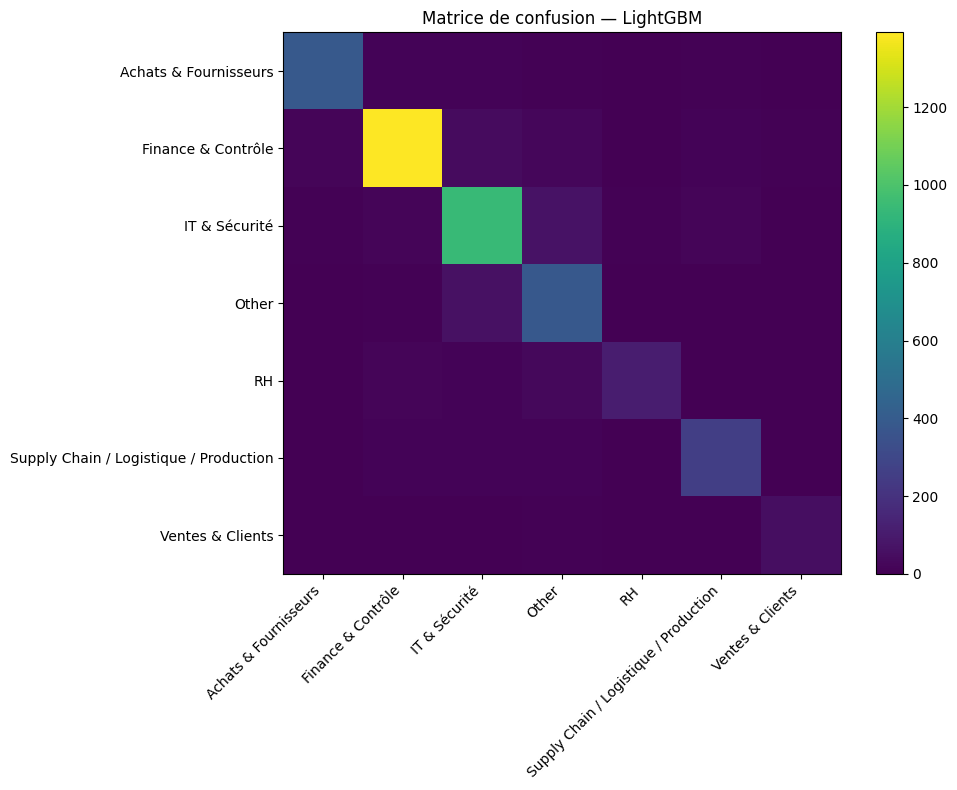

In [ ]:
if RUN_LIGHTGBM:
    lgbm_model = LGBMClassifier(
        objective="multiclass",
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=63,
        max_depth=-1,
        subsample=0.9,
        colsample_bytree=0.8,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        verbose=-1,
    )

    lgbm_model.fit(X_train_final_sparse, y_train)

    lgbm_preds = lgbm_model.predict(X_test_final_sparse)

    lgbm_eval = evaluate_predictions(
        y_test,
        lgbm_preds,
        label_encoder,
        model_name="LightGBM"
    )

    results_summary.append(
        {
            "model": "LightGBM",
            "macro_f1": lgbm_eval["macro_f1"],
            "weighted_f1": lgbm_eval["weighted_f1"],
        }
    )

## Importance des variables — LightGBM
Les importances ci-dessous sont utiles pour repérer quelles composantes dominent,
mais il faut garder en tête que les features texte sont ici des **composantes SVD**.

,feature,importance
429,finance_keyword_count,1355
221,column_value_semantics_text__svd_2,1242
14,technical_name__svd_15,1038
93,source_ref__svd_44,990
91,source_ref__svd_42,988
89,source_ref__svd_40,970
107,column_names_text__svd_8,944
108,column_names_text__svd_9,941
44,technical_name__svd_45,940
34,technical_name__svd_35,932


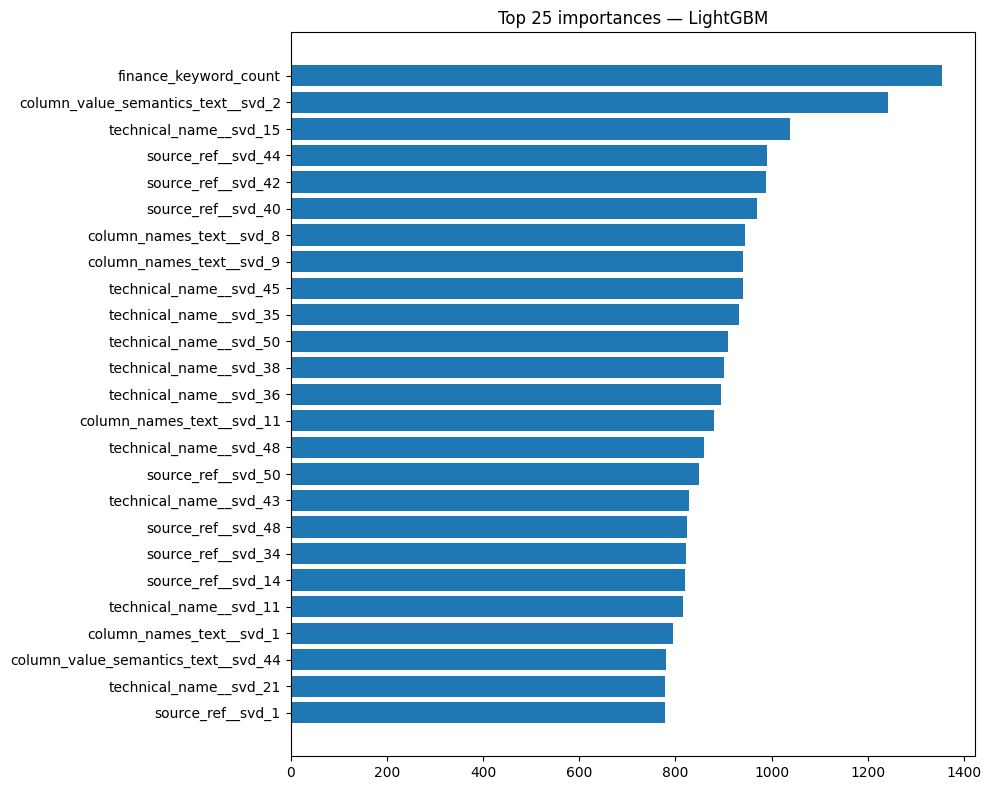

In [ ]:
if RUN_LIGHTGBM:
    importances_df = pd.DataFrame(
        {
            "feature": all_sparse_feature_names,
            "importance": lgbm_model.feature_importances_,
        }
    ).sort_values("importance", ascending=False)

    display(importances_df.head(40))

    plt.figure(figsize=(10, 8))
    top_plot = importances_df.head(25).iloc[::-1]
    plt.barh(top_plot["feature"], top_plot["importance"])
    plt.title("Top 25 importances — LightGBM")
    plt.tight_layout()
    plt.show()

## Modèle 2 — CatBoost
Ici on utilise :
- les composantes texte compressées (SVD) sous forme **dense**
- les numériques bruts + engineered features
- les variables catégorielles natives pour CatBoost

In [ ]:
def build_catboost_matrices(X_train, X_test, text_blocks, tab_blocks):
    X_train_catboost = pd.concat(
        [
            text_blocks["X_train_text_dense"],
            tab_blocks["numeric_train_df"],
            X_train[CAT_COLS],
        ],
        axis=1
    ).copy()

    X_test_catboost = pd.concat(
        [
            text_blocks["X_test_text_dense"],
            tab_blocks["numeric_test_df"],
            X_test[CAT_COLS],
        ],
        axis=1
    ).copy()

    # CatBoost gère mieux les catégorielles si elles sont bien typées en string
    for col in CAT_COLS:
        X_train_catboost[col] = X_train_catboost[col].astype(str)
        X_test_catboost[col] = X_test_catboost[col].astype(str)

    cat_feature_indices = [X_train_catboost.columns.get_loc(col) for col in CAT_COLS]

    return X_train_catboost, X_test_catboost, cat_feature_indices

In [ ]:
if RUN_CATBOOST:
    X_train_catboost, X_test_catboost, cat_feature_indices = build_catboost_matrices(
        X_train,
        X_test,
        text_blocks,
        tab_blocks,
    )

    print("X_train_catboost :", X_train_catboost.shape)
    print("X_test_catboost  :", X_test_catboost.shape)
    print("Cat features idx :", cat_feature_indices[:10])

X_train_catboost : (16000, 448)
X_test_catboost  : (4000, 448)
Cat features idx : [445, 446, 447]


0:	learn: 0.5306055	test: 0.5168070	best: 0.5168070 (0)	total: 1.42s	remaining: 9m 25s
100:	learn: 0.8334903	test: 0.7719269	best: 0.7719269 (100)	total: 2m 32s	remaining: 7m 30s
200:	learn: 0.8994297	test: 0.8001565	best: 0.8001565 (200)	total: 4m 57s	remaining: 4m 54s
300:	learn: 0.9265019	test: 0.8098031	best: 0.8114990 (297)	total: 7m 16s	remaining: 2m 23s
399:	learn: 0.9400865	test: 0.8160328	best: 0.8160328 (399)	total: 9m 33s	remaining: 0us

bestTest = 0.8160328373
bestIteration = 399

CatBoost - Macro F1    : 0.7875
CatBoost - Weighted F1 : 0.8301



,precision,recall,f1-score,support
Achats & Fournisseurs,0.849438,0.872979,0.861048,433.00000
Finance & Contrôle,0.961276,0.842876,0.898191,1502.00000
IT & Sécurité,0.842213,0.774741,0.807069,1061.00000
Other,0.594955,0.864224,0.704745,464.00000
RH,0.702857,0.719298,0.710983,171.00000
Supply Chain / Logistique / Production,0.768546,0.863333,0.813187,300.00000
Ventes & Clients,0.684211,0.753623,0.717241,69.00000
accuracy,0.825250,0.825250,0.825250,0.82525
macro avg,0.771928,0.813011,0.787495,4000.00000
weighted avg,0.844813,0.825250,0.830061,4000.00000


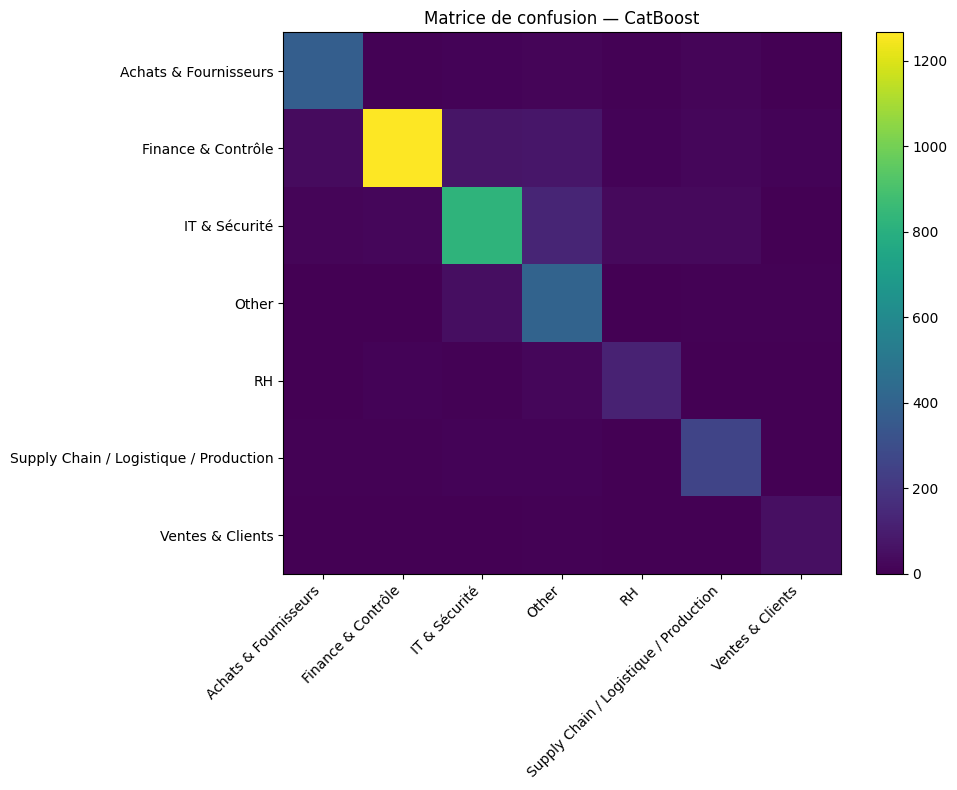

In [ ]:
if RUN_CATBOOST:
    catboost_model = CatBoostClassifier(
        loss_function="MultiClass",
        iterations=400,
        learning_rate=0.05,
        depth=8,
        auto_class_weights="Balanced",
        eval_metric="TotalF1",
        random_seed=RANDOM_STATE,
        verbose=100,
    )

    catboost_model.fit(
        X_train_catboost,
        y_train,
        cat_features=cat_feature_indices,
        eval_set=(X_test_catboost, y_test),
        use_best_model=True,
    )

    catboost_preds = catboost_model.predict(X_test_catboost)
    catboost_preds = np.array(catboost_preds).reshape(-1).astype(int)

    catboost_eval = evaluate_predictions(
        y_test,
        catboost_preds,
        label_encoder,
        model_name="CatBoost"
    )

    results_summary.append(
        {
            "model": "CatBoost",
            "macro_f1": catboost_eval["macro_f1"],
            "weighted_f1": catboost_eval["weighted_f1"],
        }
    )

## Comparaison des modèles

In [ ]:
results_df = pd.DataFrame(results_summary).sort_values("macro_f1", ascending=False)
display(results_df)

,model,macro_f1,weighted_f1
1,LightGBM,0.837700,0.881301
2,CatBoost,0.787495,0.830061
0,LinearSVC baseline,0.156864,0.300070


## Exemples d’erreurs
Permet de voir des lignes mal classées pour inspection métier.

In [ ]:
def build_error_analysis_frame(X_test_original, y_true, y_pred, label_encoder):
    out = X_test_original.copy()
    out["y_true"] = label_encoder.inverse_transform(y_true)
    out["y_pred"] = label_encoder.inverse_transform(y_pred)
    out["is_error"] = (out["y_true"] != out["y_pred"]).astype(int)
    return out

if RUN_LIGHTGBM:
    error_df_lgbm = build_error_analysis_frame(X_test, y_test, lgbm_preds, label_encoder)
    display(
        error_df_lgbm.loc[error_df_lgbm["is_error"] == 1, [
            "technical_name",
            "source_ref",
            "column_names_text",
            "column_value_semantics_text",
            "y_true",
            "y_pred",
        ]].head(20)
    )

,technical_name,source_ref,column_names_text,column_value_semantics_text,y_true,y_pred
18738,spb scr tao,ps spb scr tao,business unit process instance spb avg fil by ...,business unit label process instance processin...,Achats & Fournisseurs,Finance & Contrôle
12689,ee prcs stp lng,ps ee prcs stp lng,descr ee event step ee process language cd,descr label ee event step label ee process pro...,IT & Sécurité,Other
6943,sysadm ps proj txp typ lg,ps proj txp typ lg,debit credit descr descrshort effdt language c...,debit credit label descr label descrshort labe...,Finance & Contrôle,Other
9657,sysadm ps vendor conver,ps vendor conver,cntct seq num conver dt conver seq num conver ...,cntct seq num quantity conver dt date or times...,Achats & Fournisseurs,IT & Sécurité
13006,eodi xfr reg,ps eodi xfr reg,descr eodi class id eodi package name eodi pat...,descr label eodi class id classification eodi ...,IT & Sécurité,Other
17786,re sar rep grp,ps re sar rep grp,six months sixty days thirty days,six months quantity sixty days quantity thirty...,Other,IT & Sécurité
5646,sysadm ps ord hold,ps ord hold,active hold dttm business unit eff status hold...,active hold dttm flag business unit label eff ...,Ventes & Clients,Supply Chain / Logistique / Production
19098,title tbl,ps title tbl,descr effdt eff status title,descr label effdt date or timestamp eff status...,RH,Other
12089,conv dt tbl,ps conv dt tbl,begin depr dt begin dt calendar id convention ...,begin depr dt date or timestamp begin dt date ...,Finance & Contrôle,Other
420,sysadm ps ap search crit,ps ap search crit,fieldname label id search name,fieldname label label id label search name label,Finance & Contrôle,Other


## Sauvegarde des artefacts
On sauvegarde :
- le modèle LightGBM
- le modèle CatBoost
- le label encoder
- les objets de transformation texte
- le one-hot encoder
- la configuration

Tu pourras ensuite recharger ces éléments pour l’inférence.

In [ ]:
artifacts = {
    "label_encoder": label_encoder,
    "text_objects": text_blocks["fitted_objects"],
    "one_hot_encoder": tab_blocks["ohe"],
    "config": {
        "TARGET": TARGET,
        "DROP_COLS": DROP_COLS,
        "TEXT_COLS_CHAR": TEXT_COLS_CHAR,
        "TEXT_COLS_WORD": TEXT_COLS_WORD,
        "NUM_COLS": NUM_COLS,
        "CAT_COLS": CAT_COLS,
        "CHAR_MAX_FEATURES": CHAR_MAX_FEATURES,
        "WORD_MAX_FEATURES": WORD_MAX_FEATURES,
        "CHAR_SVD_COMPONENTS": CHAR_SVD_COMPONENTS,
        "WORD_SVD_COMPONENTS": WORD_SVD_COMPONENTS,
    },
}

if RUN_LIGHTGBM:
    artifacts["lightgbm_model"] = lgbm_model

if RUN_CATBOOST:
    artifacts["catboost_model"] = catboost_model

OUTPUT_DIR = Path("artifacts_business_domain")
OUTPUT_DIR.mkdir(exist_ok=True)

joblib.dump(artifacts, OUTPUT_DIR / "business_domain_pipeline_artifacts.joblib")
results_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)

print("Artefacts sauvegardés dans :", OUTPUT_DIR.resolve())
print(list(OUTPUT_DIR.iterdir()))

Artefacts sauvegardés dans : C:\Users\Salem\Desktop\Projets\pfe\Projet\LLM\artifacts_business_domain
[WindowsPath('artifacts_business_domain/business_domain_pipeline_artifacts.joblib'), WindowsPath('artifacts_business_domain/model_comparison.csv')]
